In [ ]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
from simulations.src import *
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

# G = get_G_class(manifold_type, uniform_sampler, 'uniform', {})
# G = get_G_class(manifold_type, equator_sampler, 'equator', {'tau2' : 0.001})

# n_samples_ls = [500, 1000, 5000, 10000, 15000, 20000]
# M_grid =  [1,2,3,4,5,6,7,8,9,10] # [1,2,3,4,5,6,7,8,9,10,15,20,30,40,50,60]
# rho_grid = [1e-3]


# S1

In [2]:
manifold_type = 'S1'; manifold = get_manifold(manifold_type)

G =  get_G_class(manifold_type, multimodal_sampler, '2-modal', {'tau2' : 0.05, 'num_modes' : 2})

sigma2 = 0.1

NMC = 5

n_samples_ls = [500, 1000, 5000, 10000]

test_size = 1000
num_oracle_samples = 20000


rho_grid = [0.5, 0.25, 1e-1, 0.05, 0.025, 1e-2, 1e-4, 1e-6, 1e-8]
M_grid =  [1,2,3,4,5,6,7,8,9,10,15,20]


In [3]:
rate_df = converenge_rate_experiment__ORACLE(manifold_type, G, n_samples_ls, M_grid, rho_grid, sigma2, test_size, num_oracle_samples, NMC)

,G,sigma2,num_samples,M_star,rho_star,mean_emp_loss,std_emp_loss,mean_oracle_loss,std_oracle_loss,mean_displacement,std_displacement,mean_excess_loss,std_excess_loss
0,2-modal,0.1,500,4,0.250,0.040960,0.002496,0.034124,0.001187,0.004565,0.000706,0.006837,0.001680
1,2-modal,0.1,1000,6,0.050,0.038351,0.001616,0.036073,0.000992,0.003747,0.000741,0.002278,0.001511
2,2-modal,0.1,5000,7,0.025,0.035320,0.000912,0.035420,0.001002,0.001629,0.000294,-0.000100,0.000469
3,2-modal,0.1,10000,7,0.025,0.036865,0.001215,0.036769,0.001107,0.001739,0.000319,0.000096,0.000683


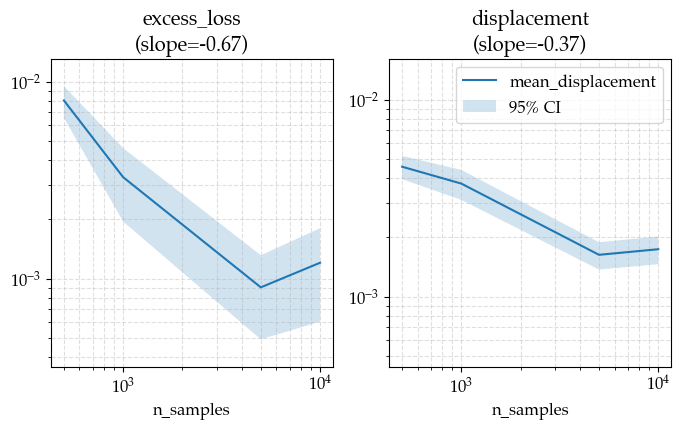

In [14]:
fig, axs = plt.subplots(figsize=(8,4), ncols = 2, sharey = False)
display(rate_df.sort_values("num_samples")
        # [['num_samples', 'M_star', 'rho_star', 'mean_excess_loss', 'mean_displacement']]
        )

for variable, ax in zip( [ 'excess_loss', 'displacement'], axs):
    df_rec = rate_df.sort_values("num_samples").copy()
    df_rec['mean_excess_loss'] = df_rec['mean_emp_loss'] -  (df_rec['mean_oracle_loss'] - df_rec['std_oracle_loss'])

    x = df_rec["num_samples"].to_numpy(dtype=float)
    y = df_rec["mean_" + variable].to_numpy(dtype=float)

    ci  = 1.96 * df_rec["std_" + variable].to_numpy(dtype=float) / np.sqrt(NMC)

    # avoid log(0) / negative values
    eps = 0
    y_plot = np.clip(y, eps, None); y_lo = np.clip(y - ci, eps, None); y_hi = np.clip(y + ci, eps, None)
    ax.plot(x, y_plot,label="mean_displacement")
    ax.fill_between(x, y_lo, y_hi, alpha=0.2, label="95% CI")

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("n_samples")
    ax.grid(True, which="both", ls="--", alpha=0.4)

    # fit in log-log space: log(y) = a + b*log(x)
    b, a = np.polyfit(np.log(x)[np.log(y) == np.log(y)], np.log(y)[np.log(y) == np.log(y)], 1)
    ax.set_title(f"{variable}\n(slope={b:.2f})")
    ax.set_aspect("equal", adjustable="datalim")
plt.legend()
plt.show()


-----

# S2

In [6]:
manifold_type = 'S2'; manifold = get_manifold(manifold_type)

# G_sampler_ls = [ get_G_class(manifold_type, uniform_sampler, 'uniform', {})]
G =  get_G_class(manifold_type, multimodal_sampler, '2-modal', {'tau2' : 0.05, 'num_modes' : 2})
# G = get_G_class(manifold_type, equator_sampler, 'equator', {'tau2' : 0.001})

sigma2 = 0.1

test_size = 2500
num_oracle_samples = 2500

NMC = 5

n_samples_ls = [500, 1000, 5000, 10000]

test_size = 1000
num_oracle_samples = 5000
M_grid =  [1,2,3,4,5,6,7,8,9,10] # [1,2,3,4,5,6,7,8,9,10,15,20,30,40,50,60]

rho_grid = [0.5, 0.25, 1e-1, 0.05, 0.025, 1e-2, 1e-4,1e-6,1e-8]

In [7]:
rate_df = converenge_rate_experiment__ORACLE(manifold_type, G, n_samples_ls, M_grid, rho_grid, sigma2, test_size, num_oracle_samples, NMC)

/var/folders/4l/9wthfjb520bf_3mctz_1csd00000gn/T/ipykernel_7090/2898527544.py:20: RuntimeWarning: invalid value encountered in log
  b, a = np.polyfit(np.log(x)[np.log(y) == np.log(y)], np.log(y)[np.log(y) == np.log(y)], 1)


   num_samples  M_star  rho_star  mean_excess_loss  mean_displacement
0          500       5     0.100          0.019396           0.011240
1         1000       5     0.100          0.016807           0.010575
2         5000       7     0.025          0.003920           0.006711
3        10000       7     0.010         -0.000392           0.005485


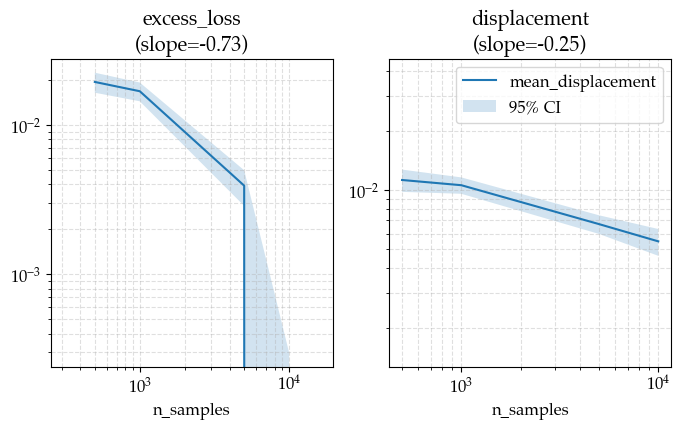

In [ ]:
fig, axs = plt.subplots(figsize=(8,4), ncols = 2, sharey = False)
display(rate_df.sort_values("num_samples")
        # [['num_samples', 'M_star', 'rho_star', 'mean_excess_loss', 'mean_displacement']]
        )

for variable, ax in zip( [ 'excess_loss', 'displacement'], axs):
    df_rec = rate_df.sort_values("num_samples").copy()
    df_rec['mean_excess_loss'] = df_rec['mean_emp_loss'] -  (df_rec['mean_oracle_loss'] - df_rec['std_oracle_loss'])

    x = df_rec["num_samples"].to_numpy(dtype=float)
    y = df_rec["mean_" + variable].to_numpy(dtype=float)

    ci  = 1.96 * df_rec["std_" + variable].to_numpy(dtype=float) / np.sqrt(NMC)

    # avoid log(0) / negative values
    eps = 0
    y_plot = np.clip(y, eps, None); y_lo = np.clip(y - ci, eps, None); y_hi = np.clip(y + ci, eps, None)
    ax.plot(x, y_plot,label="mean_displacement")
    ax.fill_between(x, y_lo, y_hi, alpha=0.2, label="95% CI")

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("n_samples")
    ax.grid(True, which="both", ls="--", alpha=0.4)

    # fit in log-log space: log(y) = a + b*log(x)
    b, a = np.polyfit(np.log(x)[np.log(y) == np.log(y)], np.log(y)[np.log(y) == np.log(y)], 1)
    ax.set_title(f"{variable}\n(slope={b:.2f})")
    ax.set_aspect("equal", adjustable="datalim")
plt.legend()
plt.show()


-----